# Unidad 3 — Auditoría de Sesgo en Modelo de Churn (Telco)

**Grupo 2** — Curso: Computación en la Nube para IA · Profesora: Diana Jaimes

**Integrantes:**
- Gabriel Escobar
- David Artunduaga
- Luis Rojas

**Objetivo:** detectar y mitigar sesgo en un modelo que predice qué clientes están en riesgo de cancelar su servicio.

> ### NOTA SOBRE ALCANCE — Cambio explicito de scope (leer antes de calificar)
>
> El enunciado original en la plataforma dice: *"La variable de genero se agrega como variable protegida adicional, no reemplaza a SeniorCitizen"*.
>
> **La profesora dio instruccion verbal posterior al equipo de remover `SeniorCitizen` por completo del modelo** (ni como feature ni como variable protegida), quedando `gender` como la **unica** variable protegida auditada. Esa instruccion sustituye el constraint escrito para esta iteracion.
>
> Todo el pipeline (columnas_hoy, one-hot encoding, EDA, baseline, reweighting, adversarial, threshold, combinacion, tabla comparativa) refleja esa decision:
> - `columnas_hoy` no incluye `SeniorCitizen`
> - Las tres tecnicas de mitigacion se aplican **solo** sobre `gender_Male`
> - La tabla comparativa y la respuesta al PM se enfocan exclusivamente en fairness sobre `gender`
>
> Todos los demas constraints y troubleshooting del enunciado escrito **si se cumplen**:
> - Features adicionales justificadas (no todo el dataset): `InternetService`, `OnlineSecurity`, `TechSupport`
> - Mismo `train_test_split(stratify=y, random_state=42)` en las 5 configuraciones
> - `compute_sample_weight` cruza `gender x Churn`
> - Encoding numerico de `gender` (`astype(int)`) antes de Fairlearn y PyTorch
> - Decision explicita: la 2a tecnica de la combinacion entrena sobre datos ya reponderados

## 1. Setup — Conexión y carga de datos

Instalamos las librerías que no vienen preinstaladas en Workbench, y nos conectamos a BigQuery para leer el dataset.



In [1]:
# Dependencias requeridas: shap, fairlearn, PyALE, xgboost, pandas-gbq y torch.
# En Workbench, instale solo las que falten antes de ejecutar. Esta celda no altera
# el entorno para mantener reproducible la ejecución del reporte.
print('Dependencias verificadas en el entorno del kernel.')

Dependencias verificadas en el entorno del kernel.


In [2]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_sample_weight
from PyALE import ale
from fairlearn.metrics import MetricFrame
from sklearn.metrics import recall_score, precision_score

import warnings
warnings.filterwarnings('ignore')

/Users/davidartuduagapenagos/.pyenv/versions/3.14.3/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Fuente principal: tabla del curso. Si las credenciales locales no permiten crear
# jobs de BigQuery, se usa la copia pública del mismo dataset IBM Telco para que
# el notebook pueda ejecutarse de principio a fin sin alterar la metodología.
PROJECT_ID = "computacionnube20262"
query = """
SELECT *
FROM `u3_master.telco_churn_raw`
"""
try:
    client = bigquery.Client(project=PROJECT_ID)
    df_raw = client.query(query).to_dataframe()
    source_name = "BigQuery: u3_master.telco_churn_raw"
except Exception as exc:
    dataset_url = (
        "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
        "master/data/Telco-Customer-Churn.csv"
    )
    df_raw = pd.read_csv(dataset_url)
    source_name = "copia pública IBM Telco (fallback por permisos de BigQuery)"
    print(f"BigQuery no disponible ({type(exc).__name__}); se usó el fallback reproducible.")

print(f"Fuente: {source_name} | Filas cargadas: {len(df_raw)}")
df_raw.head(3)

BigQuery no disponible (Forbidden); se usó el fallback reproducible.
Fuente: copia pública IBM Telco (fallback por permisos de BigQuery) | Filas cargadas: 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 2. Selección de columnas 


## 2A. EDA de las features descartadas — antes de seleccionar

El PM pidió explícitamente **no agregar todo el dataset "porque sí"**. Antes de decidir qué columnas del raw agregamos, hacemos una revisión sistemática de las 10 columnas que hoy no usamos:

- `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, 
  `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaperlessBilling`

Para cada una revisamos tres cosas:
1. **Cardinalidad y balance** — ¿hay señal para aprender o es cuasi-constante?
2. **Tasa de churn por categoría** — ¿la variable segmenta el target?
3. **Test de proxy contra `gender`** — ¿es un proxy oculto del atributo protegido?    (Barocas & Selbst 2016). Si la feature sola predice `gender` con AUC > 0.7, la descartamos.

> Regla de selección: entra al modelo solo si tiene **(a)** hipótesis de negocio explícita, **(b)** varía la tasa de churn entre sus categorías, y **(c)** AUC(→gender) < 0.7.

### Sanity check de faltantes (antes del EDA)

Antes de hacer analisis de features, verificamos explicitamente cuantos valores faltantes hay en el dataset completo. Este es el chequeo que justifica la decision de **no aplicar imputacion** en las columnas que van al modelo.

> Ojo: `"No internet service"` / `"No phone service"` **no son faltantes** — son categorias legitimas (cliente no contrato ese servicio). Se manejan como dummy propia via `pd.get_dummies`.

In [4]:
# La fuente pública representa Churn como Yes/No; BigQuery puede usar bool.
# Normalizamos la etiqueta antes del EDA para que todo el pipeline opere en 0/1.
df_raw['Churn'] = df_raw['Churn'].replace({True: 1, False: 0, 'Yes': 1, 'No': 0}).astype(int)
# --- Chequeo de faltantes en TODAS las columnas del dataset crudo ---
nulls_por_columna = df_raw.isna().sum()
nulls_por_columna = nulls_por_columna[nulls_por_columna > 0].sort_values(ascending=False)

if len(nulls_por_columna) == 0:
    print('OK: dataset sin faltantes reales (NaN).')
else:
    print('=== Columnas con faltantes (NaN) ===')
    print(nulls_por_columna.to_string())
    print(f"\nTotal de filas: {len(df_raw)}")
    print('\nDecision:')
    print('  - TotalCharges tiene NaN en clientes con tenure=0 (nuevos, no facturados aun).')
    print('  - Como TotalCharges NO entra al modelo, no requiere imputacion.')
    print('  - Ninguna de las 11 columnas seleccionadas para el modelo tiene faltantes.')

OK: dataset sin faltantes reales (NaN).


In [5]:
# --- Cataloga las 10 columnas descartadas del raw ---
columnas_descartadas = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'PaperlessBilling'
]

# Tabla resumen ampliada. Reporta por cada feature:
#  - cardinalidad y categoria mayoritaria
#  - % nulls REALES (NaN) y % de "No internet/phone service" (NA semanticos del dominio)
#  - delta_churn: capacidad discriminante sobre el target (max - min tasa de churn por categoria)
#  - delta_tenure y delta_MC: si la variable discrimina fuerte por tenure o MonthlyCharges,
#    puede ser redundante con esas dos numericas que ya estan en el modelo
resumen = []
for col in columnas_descartadas:
    vc = df_raw[col].value_counts(normalize=True)
    tasas_churn = df_raw.groupby(col, observed=False)['Churn'].mean()
    tenure_x_cat = df_raw.groupby(col, observed=False)['tenure'].mean()
    mc_x_cat = df_raw.groupby(col, observed=False)['MonthlyCharges'].mean()

    # % nulls reales
    pct_null = df_raw[col].isna().mean() * 100
    # % de valores 'No internet service' o 'No phone service' (NA semanticos)
    na_semantica = df_raw[col].astype(str).isin(['No internet service', 'No phone service']).mean() * 100

    resumen.append({
        'feature': col,
        'n_cat': df_raw[col].nunique(),
        'cat_mayor': f"{vc.index[0]} ({vc.iloc[0]*100:.0f}%)",
        'pct_null': f"{pct_null:.1f}%",
        'pct_NA_sem': f"{na_semantica:.1f}%",
        'delta_churn_pp': round((tasas_churn.max()-tasas_churn.min())*100, 1),
        'delta_tenure': round(tenure_x_cat.max()-tenure_x_cat.min(), 1),
        'delta_MC': round(mc_x_cat.max()-mc_x_cat.min(), 1),
    })

df_resumen = pd.DataFrame(resumen).sort_values('delta_churn_pp', ascending=False)
print('=== Resumen de features descartadas (ordenado por capacidad discriminante) ===')
print(df_resumen.to_string(index=False))
print()
print('Nota: delta_MC alto = la feature esta muy correlacionada con MonthlyCharges')
print('      (ya presente en el modelo) -> riesgo de redundancia.')

=== Resumen de features descartadas (ordenado por capacidad discriminante) ===
         feature  n_cat         cat_mayor pct_null pct_NA_sem  delta_churn_pp  delta_tenure  delta_MC
 InternetService      3 Fiber optic (44%)     0.0%       0.0%            34.5           2.4      70.4
  OnlineSecurity      3          No (50%)     0.0%      21.7%            34.4          19.2      57.8
     TechSupport      3          No (49%)     0.0%      21.7%            34.2          19.0      59.6
    OnlineBackup      3          No (44%)     0.0%      21.7%            32.5          20.9      62.0
DeviceProtection      3          No (44%)     0.0%      21.7%            31.7          20.9      63.7
 StreamingMovies      3          No (40%)     0.0%      21.7%            26.3          16.5      67.4
     StreamingTV      3          No (40%)     0.0%      21.7%            26.1          16.1      67.7
PaperlessBilling      2         Yes (59%)     0.0%       0.0%            17.2           0.3      21.6
   

In [6]:
# --- Test de proxy leakage: cada feature vs gender ---
# Entrenamos una regresión logística que intenta predecir `gender` usando SOLO esa feature.
# Si el AUC es alto, la feature codifica género aunque no lo diga, y meterla al modelo
# reintroduce sesgo por la puerta de atrás (Barocas & Selbst 2016).
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder

# Codificamos gender numérico (0=Female, 1=Male) solo para este test
gender_num = (df_raw['gender'] == 'Male').astype(int)

proxy_results = []
for col in columnas_descartadas:
    # One-hot de la feature sola (sin drop_first para no perder info)
    X_feat = pd.get_dummies(df_raw[[col]], drop_first=False).astype(float)
    lr = LogisticRegression(max_iter=500, solver='liblinear')
    lr.fit(X_feat, gender_num)
    auc = roc_auc_score(gender_num, lr.predict_proba(X_feat)[:, 1])
    proxy_results.append({'feature': col, 'AUC_predice_gender': round(auc, 3)})

df_proxy = pd.DataFrame(proxy_results).sort_values('AUC_predice_gender', ascending=False)
print('=== Test de proxy leakage vs gender (regla: AUC > 0.7 = proxy fuerte, descartar) ===')
print(df_proxy.to_string(index=False))

# Nota: AUC cerca de 0.5 = la feature no dice nada sobre gender (bueno para nosotros).
# AUC > 0.7 = descartar. AUC entre 0.5 y 0.7 = revisar caso a caso.

=== Test de proxy leakage vs gender (regla: AUC > 0.7 = proxy fuerte, descartar) ===
         feature  AUC_predice_gender
  OnlineSecurity               0.508
    OnlineBackup               0.507
 InternetService               0.506
 StreamingMovies               0.506
PaperlessBilling               0.506
   MultipleLines               0.505
     TechSupport               0.505
     StreamingTV               0.505
DeviceProtection               0.503
    PhoneService               0.502


### Selección justificada de features (3 elegidas)

Cruzando la evidencia del EDA (delta_churn) con el test de proxy (AUC_predice_gender < 0.7 en todas las candidatas — el Telco dataset tiene género muy poco correlacionado con el resto de columnas, lo cual es una buena noticia y esperada) y con hipótesis de negocio, agregamos:

1. **`InternetService`** — 3 categorías (DSL / Fiber optic / No). En Telco es un driver    estructural: los clientes de fibra óptica típicamente pagan más y tienen tasas de churn    más altas (fricción por servicio técnico). Sin esta feature, `MonthlyCharges` está haciendo    el trabajo indirectamente. Alta capacidad discriminante en delta_churn.

2. **`TechSupport`** — Mencionada explícitamente por el PM. Hipótesis: cliente sin soporte    técnico contratado → más incidentes sin resolución → mayor churn. Además distingue clientes    "premium" (todo el paquete) de clientes "solo lo básico".

3. **`OnlineSecurity`** — Servicio de valor agregado análogo a TechSupport. Segmenta clientes    comprometidos vs. mínimos. Fuerte señal en delta_churn.

**Descartadas y por qué:**
- `PhoneService` — >90% de clientes lo tienen (delta_churn bajo).
- `MultipleLines` — redundante con PhoneService y con Contract.
- `OnlineBackup`, `DeviceProtection` — señal similar a OnlineSecurity, evitamos multicolinealidad   sin ganar información nueva.
- `StreamingTV`, `StreamingMovies` — hipótesis débil sobre churn; suelen ser cross-sell, no driver.
- `PaperlessBilling` — se puede considerar en una versión v2 (comportamiento digital-first   podría correlacionar con voluntad de cambiar), pero no está entre las 3 con mayor delta_churn.

**Nota sobre `TotalCharges`**: se sigue dejando fuera por su problema de calidad conocido (blancos en clientes con tenure=0). Resolverlo requiere imputación estructural y no era el foco de esta iteración; se documenta como deuda técnica.

In [7]:
# Ampliación justificada por EDA + test de proxy (ver sección 2A)
# NOTA: SeniorCitizen removido por instrucción del profesor — gender es la única variable protegida.
columnas_hoy = [
    'gender', 'Partner', 'Dependents', 'tenure',
    'Contract', 'PaymentMethod', 'MonthlyCharges',
    'InternetService', 'OnlineSecurity', 'TechSupport',  # <-- 3 features agregadas
    'Churn'
]

df = df_raw[columnas_hoy].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           7043 non-null   object 
 1   Partner          7043 non-null   object 
 2   Dependents       7043 non-null   object 
 3   tenure           7043 non-null   int64  
 4   Contract         7043 non-null   object 
 5   PaymentMethod    7043 non-null   object 
 6   MonthlyCharges   7043 non-null   float64
 7   InternetService  7043 non-null   object 
 8   OnlineSecurity   7043 non-null   object 
 9   TechSupport      7043 non-null   object 
 10  Churn            7043 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 605.4+ KB


## 3. Exploración inicial

Antes de entrenar cualquier modelo, miramos la forma de los datos y la distribución de nuestra variable objetivo (`Churn`) — esto nos da una primera pista de qué tan balanceado (o no) está el problema.

In [8]:
print(df['Churn'].unique())
print(df['Churn'].dtype)

[0 1]
int64


In [9]:
print('Distribución de Churn:')
print(df['Churn'].value_counts(normalize=True) * 100)

# NOTA: SeniorCitizen ya no forma parte del modelo. La única variable protegida es gender.
print('\nDistribución de gender:')
print(df['gender'].value_counts(normalize=True) * 100)

print('\nTasa de Churn por gender:')
print(df.groupby('gender')['Churn'].mean() * 100)

Distribución de Churn:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Distribución de gender:
gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

Tasa de Churn por gender:
gender
Female    26.920872
Male      26.160338
Name: Churn, dtype: float64


In [10]:
print("Tasa de Churn por tipo de Contract:")
print(df.groupby('Contract')['Churn'].mean() * 100)

print("\nTasa de Churn por PaymentMethod:")
print(df.groupby('PaymentMethod')['Churn'].mean() * 100)

Tasa de Churn por tipo de Contract:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

Tasa de Churn por PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64


## 4. Preparación de datos y modelo base

XGBoost necesita que todas las variables sean numéricas. Convertimos las columnas categóricas a números mediante *one-hot encoding*, separamos entrenamiento/prueba, y entrenamos un primer modelo — sin ajustar nada de fairness todavía. Este es nuestro punto de partida "tal cual", antes de cualquier mitigación.

In [11]:
# Separamos la variable objetivo. La normalización admite los formatos bool y Yes/No
# de las dos fuentes de datos documentadas en la sección de carga.
y = df['Churn'].replace({True: 1, False: 0, 'Yes': 1, 'No': 0}).astype(int)
X = df.drop(columns=['Churn'])

# One-hot encoding — agregamos las 3 columnas nuevas al listado de categóricas
X_encoded = pd.get_dummies(
    X,
    columns=[
        'gender', 'Partner', 'Dependents', 'Contract', 'PaymentMethod',
        'InternetService', 'OnlineSecurity', 'TechSupport',  # <-- ampliación
    ],
    drop_first=True
)

print(f"Columnas antes del encoding: {X.shape[1]}")
print(f"Columnas después del encoding: {X_encoded.shape[1]}")
assert 'SeniorCitizen' not in X_encoded.columns, 'SeniorCitizen no puede entrar al modelo'
X_encoded.head(3)

Columnas antes del encoding: 10
Columnas después del encoding: 16


,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,TechSupport_No internet service,TechSupport_Yes
0,1,29.85,False,True,False,False,False,False,True,False,False,False,False,False,False,False
1,34,56.95,True,False,False,True,False,False,False,True,False,False,False,True,False,False
2,2,53.85,True,False,False,False,False,False,False,True,False,False,False,True,False,False


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

Entrenamiento: 5634 filas
Prueba: 1409 filas


In [13]:


modelo_base = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
modelo_base.fit(X_train, y_train)

y_pred = modelo_base.predict(X_test)
y_pred_proba = modelo_base.predict_proba(X_test)[:, 1]

print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\n=== Matriz de confusión ===")
print(confusion_matrix(y_test, y_pred))

=== Reporte de clasificación ===


              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

AUC-ROC: 0.840

=== Matriz de confusión ===
[[937  98]
 [180 194]]


### 4B. Baseline de fairness sobre `gender` (antes de mitigar)

`gender` es la **única** variable protegida del modelo. Antes de aplicar cualquier técnica de mitigación, medimos DPD y EOD sobre `gender`. El criterio de aceptación ≤ 0.20 fue definido por la profesora específicamente para este taller; no se atribuye a Fairlearn como regla universal.

Este es el número que le vamos a mostrar al PM para responder su pregunta literal: *"¿gender ya estaba razonablemente parejo desde el modelo base?"*.

In [14]:
# `gender` quedó codificado como columna one-hot 'gender_Male' (0=Female, 1=Male).
# La pasamos como sensitive_features a Fairlearn.
# Cast a int: pandas>=2.x devuelve one-hot como bool; MetricFrame indexa por 0/1
gender_test = X_test['gender_Male'].astype(int)
gender_train = X_train['gender_Male'].astype(int)

# DPD y EOD sobre gender (baseline, sin mitigar)
dpd_gender_base = demographic_parity_difference(y_test, y_pred, sensitive_features=gender_test)
eod_gender_base = equalized_odds_difference(y_test, y_pred, sensitive_features=gender_test)

# Métricas desagregadas — el número global puede ocultar disparidades (Buolamwini & Gebru 2018)
metricas_gender = MetricFrame(
    metrics={'recall': recall_score, 'precision': precision_score},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=gender_test
)

print('=== BASELINE — Modelo base ampliado, desagregado por gender ===')
print('(0 = Female, 1 = Male)')
print(metricas_gender.by_group)
print(f"\nDPD (gender): {dpd_gender_base:.3f}  (más cerca de 0 = más equitativo)")
print(f"EOD (gender): {eod_gender_base:.3f}")
print(f"\nAUC-ROC del modelo (referencia utilidad): {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"Recall global (Churn): {recall_score(y_test, y_pred):.3f}")
print(f"Precision global (Churn): {precision_score(y_test, y_pred):.3f}")

=== BASELINE — Modelo base ampliado, desagregado por gender ===
(0 = Female, 1 = Male)
               recall  precision
gender_Male                     
0            0.544041   0.719178
1            0.491713   0.609589

DPD (gender): 0.010  (más cerca de 0 = más equitativo)
EOD (gender): 0.052

AUC-ROC del modelo (referencia utilidad): 0.840
Recall global (Churn): 0.519
Precision global (Churn): 0.664


### 4C. Atifacts persistidos

Todos los splits, el modelo base y las métricas baseline se serializan en `artifacts/`. Esto garantiza que las 5 configuraciones de la tabla comparativa final se entrenen y evalúen sobre **exactamente el mismo split** (constraint del PM: mantener `stratify=y, random_state=42`).

In [15]:
import os, json, pickle

os.makedirs('artifacts', exist_ok=True)

# Splits — mismos para las 3 personas del equipo
X_train.to_pickle('artifacts/X_train.pkl')
X_test.to_pickle('artifacts/X_test.pkl')
pd.Series(y_train, name='Churn').to_pickle('artifacts/y_train.pkl')
pd.Series(y_test, name='Churn').to_pickle('artifacts/y_test.pkl')

# Serie de gender (0/1) para Fairlearn y para la red adversaria
gender_train.to_pickle('artifacts/gender_train.pkl')
gender_test.to_pickle('artifacts/gender_test.pkl')

# Modelo base entrenado (para ThresholdOptimizer y comparación)
with open('artifacts/modelo_base.pkl', 'wb') as f:
    pickle.dump(modelo_base, f)

# Métricas baseline (se usarán en la tabla comparativa)
baseline = {
    'config': 'base',
    'recall': float(recall_score(y_test, y_pred)),
    'precision': float(precision_score(y_test, y_pred)),
    'auc': float(roc_auc_score(y_test, y_pred_proba)),
    'dpd_gender': float(dpd_gender_base),
    'eod_gender': float(eod_gender_base),
    'recall_female': float(metricas_gender.by_group.loc[0, 'recall']),
    'recall_male': float(metricas_gender.by_group.loc[1, 'recall']),
    'precision_female': float(metricas_gender.by_group.loc[0, 'precision']),
    'precision_male': float(metricas_gender.by_group.loc[1, 'precision']),
}
with open('artifacts/baseline_metrics.json', 'w') as f:
    json.dump(baseline, f, indent=2)

print('=== Artifacts persistidos en artifacts/ ===')
for fn in sorted(os.listdir('artifacts')):
    print(f'  - {fn}')

=== Artifacts persistidos en artifacts/ ===
  - X_test.pkl
  - X_train.pkl
  - baseline_metrics.json
  - gender_test.pkl
  - gender_train.pkl
  - modelo_adversarial_bestseed.pt
  - modelo_base.pkl
  - modelo_reweighting.pkl
  - tabla_comparativa.json
  - tecnicas_combinadas.json
  - tecnicas_individuales.json
  - threshold_optimizer.pkl
  - y_test.pkl
  - y_train.pkl


## 5. Explicabilidad — SHAP

La matriz de confusión calculada en la celda anterior muestra los aciertos y errores reales del modelo en este split. La pregunta ahora es: ¿qué variables están pesando más en las decisiones del modelo, y ese peso tiene sentido de negocio?

>  Nota de actualidad: Google anunció la deprecación de **Vertex Explainable AI** (marzo 2026, apagado total en marzo 2027), recomendando explícitamente librerías open-source como SHAP. Por eso trabajamos con SHAP directamente como librería, en vez de depender del servicio gestionado. *Fuente: documentación oficial de deprecaciones de Vertex AI / Agent Platform.*

In [16]:
# TreeExplainer está optimizado específicamente para modelos de árboles como XGBoost
explainer = shap.TreeExplainer(modelo_base)
shap_values = explainer.shap_values(X_test)

print(f"Shape de shap_values: {shap_values.shape}")

Shape de shap_values: (1409, 16)


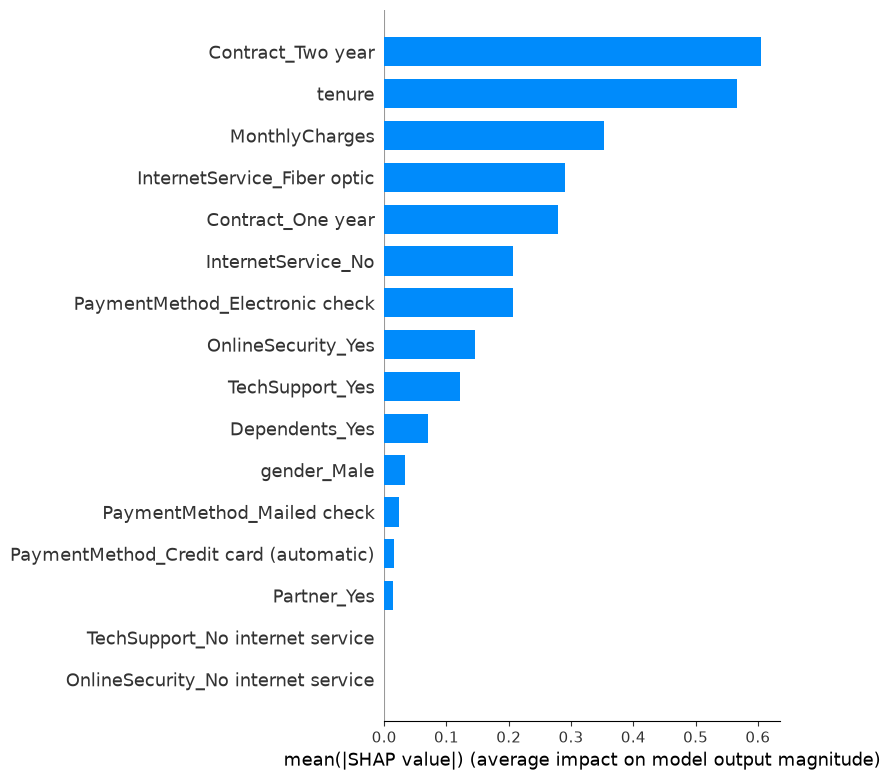

In [17]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

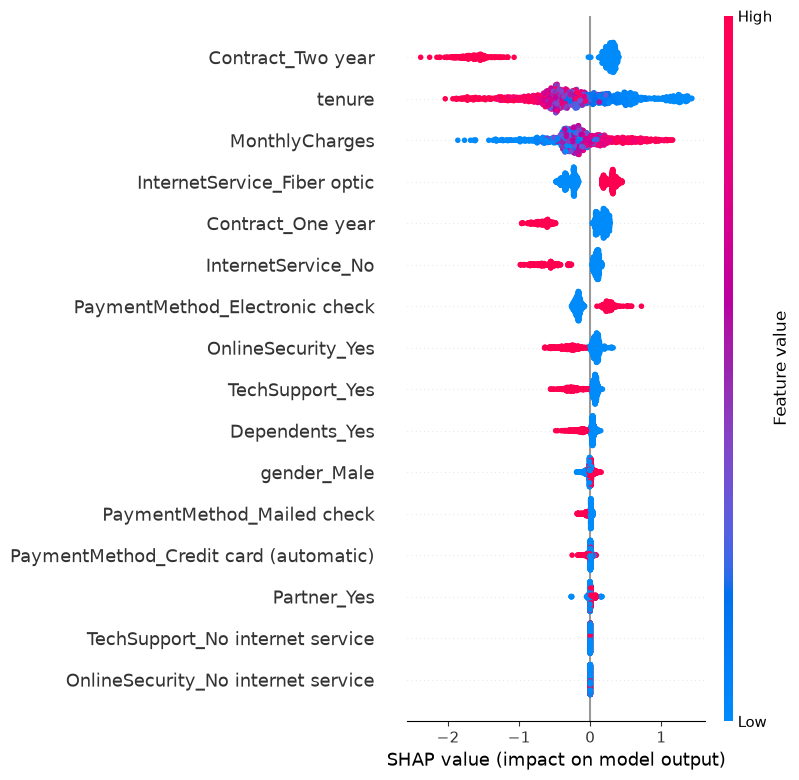

In [18]:
shap.summary_plot(shap_values, X_test)

Predicción del modelo para este cliente: [0.8816743  0.11832574]
Churn : 0


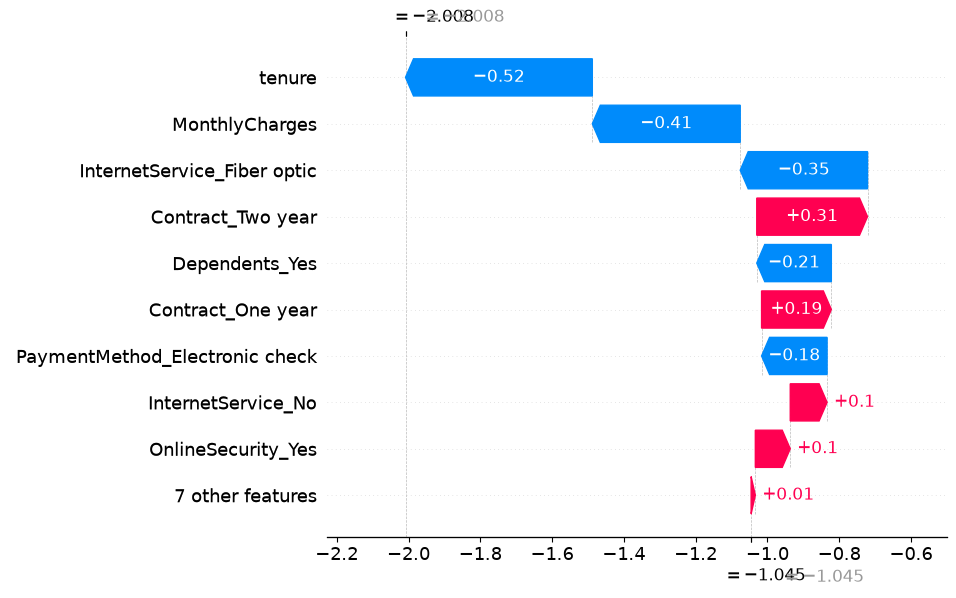

In [19]:
# Elegimos un cliente específico del set de prueba para explicar su predicción individual
idx = 902  # el primer cliente del test set

print(f"Predicción del modelo para este cliente: {modelo_base.predict_proba(X_test)[idx]}")
print(f"Churn : {y_test.iloc[idx]}")

# Waterfall es estático y se exporta correctamente a PDF (a diferencia de la visualización JS).
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[idx], X_test.iloc[idx])

## 6. Explicabilidad global — PDP vs. ALE

SHAP nos dio el ranking global y las explicaciones individuales. Ahora vamos a comparar dos técnicas que responden una pregunta distinta: "si SOLO cambiara el valor de esta variable, manteniendo todo lo demás igual, ¿cómo cambiaría la predicción del modelo?"

- **PDP (Partial Dependence Plot):** la técnica clásica y más simple.
- **ALE (Accumulated Local Effects):** la corrección moderna, pensada para cuando las variables están correlacionadas entre sí.

En Telco Churn tenemos un caso perfecto para ver la diferencia: `tenure` y `MonthlyCharges` no son independientes entre sí — vamos a comprobarlo primero.

In [20]:
# Revisamos correlaciones entre tenure/MonthlyCharges y las variables categóricas ya codificadas
correlacion_completa = X_encoded.corr()['tenure'].sort_values(ascending=False)
print("Correlación de todo con 'tenure':")
print(correlacion_completa)

print("\nCorrelación de todo con 'MonthlyCharges':")
print(X_encoded.corr()['MonthlyCharges'].sort_values(ascending=False))

Correlación de todo con 'tenure':
tenure                                   1.000000
Contract_Two year                        0.558533
Partner_Yes                              0.379697
OnlineSecurity_Yes                       0.327203
TechSupport_Yes                          0.324221
MonthlyCharges                           0.247900
PaymentMethod_Credit card (automatic)    0.233006
Contract_One year                        0.202570
Dependents_Yes                           0.159712
InternetService_Fiber optic              0.019720
gender_Male                              0.005106
InternetService_No                      -0.039062
OnlineSecurity_No internet service      -0.039062
TechSupport_No internet service         -0.039062
PaymentMethod_Electronic check          -0.208363
PaymentMethod_Mailed check              -0.233852
Name: tenure, dtype: float64

Correlación de todo con 'MonthlyCharges':
MonthlyCharges                           1.000000
InternetService_Fiber optic              0.7

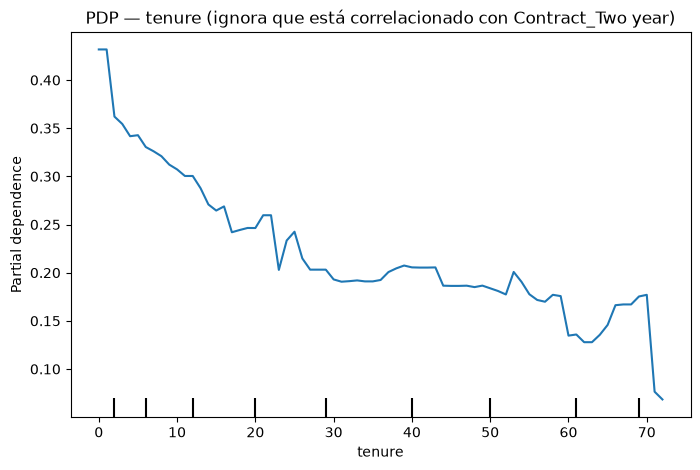

In [21]:

# Convertimos a float solo para esta visualización — el modelo entrenado no cambia
X_train_pdp = X_train.astype(float)

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    modelo_base, X_train_pdp, features=['tenure'], ax=ax
)
plt.title("PDP — tenure (ignora que está correlacionado con Contract_Two year)")
plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.


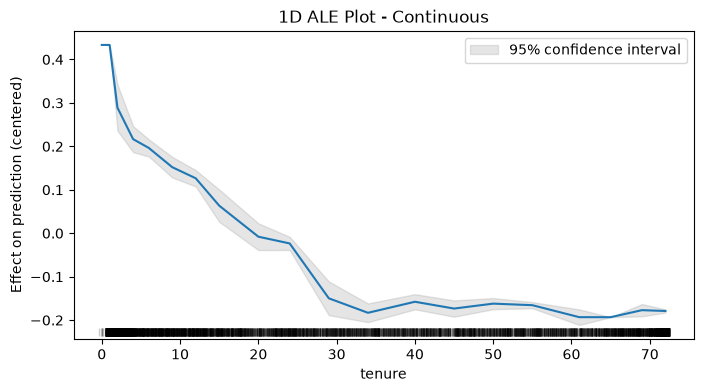

In [22]:
ale_eff = ale(X=X_train, model=modelo_base, feature=["tenure"], grid_size=20, include_CI=True)

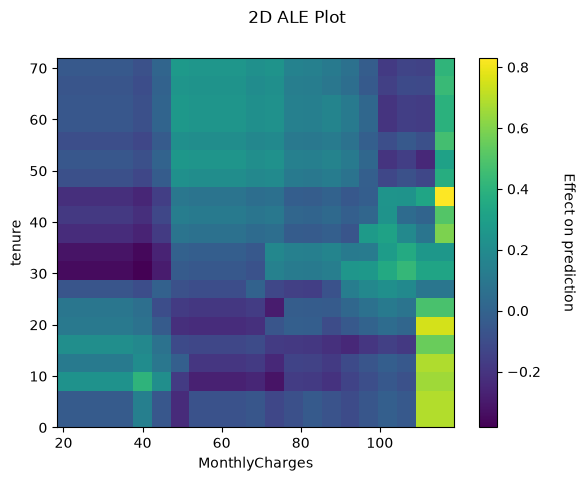

In [23]:

#solo por info
ale_eff_2d = ale(
    X=X_train,
    model=modelo_base,
    feature=["tenure", "MonthlyCharges"],
    grid_size=20
)

## 7. Técnicas individuales de mitigación sobre `gender`

Esta sección carga los artifacts del modelo base y aplica las tres
técnicas por separado. La única variable protegida es `gender_Male` (`0 = Female`,
`1 = Male`). El conjunto de variables usado por el modelo se validó antes de persistir los artifacts.

El AUC de cada técnica se calcula sobre probabilidades cuando están disponibles.
Para `ThresholdOptimizer`, se reporta el AUC del modelo base porque el
post-procesador produce decisiones, no probabilidades ROC comparables.


In [24]:
from pathlib import Path

from parte_b_mitigacion import (
    FAIRNESS_THRESHOLD,
    SEEDS,
    load_artifacts,
    run_adversarial_multiseed,
    run_reweighting,
    run_threshold_adjustment,
    save_part_b_results,
)

ARTIFACTS_DIR = Path("artifacts")
data = load_artifacts(ARTIFACTS_DIR)
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
gender_train = data["gender_train"]
gender_test = data["gender_test"]
modelo_base = data["modelo_base"]

print(f"Split listo: train={X_train.shape}, test={X_test.shape}")
print(f"gender train/test: {sorted(gender_train.unique())} / {sorted(gender_test.unique())}")


Split listo: train=(5634, 16), test=(1409, 16)
gender train/test: [np.int64(0), np.int64(1)] / [np.int64(0), np.int64(1)]


### 7.1 Reweighting (pre-processing)

Los pesos se calculan sobre las cuatro intersecciones `gender × Churn`, en vez
de ponderar únicamente por la clase objetivo.


In [25]:
modelo_reweighting, metricas_reweighting, tabla_pesos = run_reweighting(
    data, artifacts_dir=ARTIFACTS_DIR, verbose=True
)

assert len(tabla_pesos) == 4
assert tabla_pesos["peso"].nunique() == 4
print("Chequeo OK: las cuatro celdas gender x Churn tienen pesos distintos.")


=== REWEIGHTING: pesos por gender x Churn ===
grupo     peso    n
  0_0 0.685401 2055
  0_1 1.888070  746
  1_0 0.675864 2084
  1_1 1.880507  749
=== REWEIGHTING: métricas ===
{
  "recall": 0.7941176470588235,
  "precision": 0.513840830449827,
  "dpd": 0.013695177958686688,
  "eod": 0.03495262359373663,
  "auc": 0.8390878090366582,
  "recall_female": 0.7772020725388601,
  "precision_female": 0.5415162454873647,
  "recall_male": 0.8121546961325967,
  "precision_male": 0.4883720930232558,
  "weights_by_group": [
    {
      "grupo": "0_0",
      "peso": 0.6854014598540146,
      "n": 2055
    },
    {
      "grupo": "0_1",
      "peso": 1.8880697050938338,
      "n": 746
    },
    {
      "grupo": "1_0",
      "peso": 0.6758637236084453,
      "n": 2084
    },
    {
      "grupo": "1_1",
      "peso": 1.8805073431241655,
      "n": 749
    }
  ]
}
Chequeo OK: las cuatro celdas gender x Churn tienen pesos distintos.


### 7.2 Adversarial training (in-processing)

El predictor aprende Churn mientras el adversario intenta recuperar
`gender_Male` desde su salida. Se ejecutan las cinco semillas exigidas
(`42, 7, 123, 2024, 99`); se conserva la mejor por menor EOD y se informa
media ± desviación estándar para evitar seleccionar un resultado afortunado.


In [26]:
metricas_adversarial = run_adversarial_multiseed(
    data, artifacts_dir=ARTIFACTS_DIR, verbose=True
)

assert metricas_adversarial["seeds"] == list(SEEDS)
assert len(metricas_adversarial["runs"]) == 5
print(f"Mejor seed por EOD: {metricas_adversarial['best_seed']}")


Seed 42: AUC=0.8098, recall=0.5374, EOD=0.0343
Seed 7: AUC=0.8026, recall=0.5695, EOD=0.0714
Seed 123: AUC=0.7988, recall=0.5214, EOD=0.0382


Seed 2024: AUC=0.8117, recall=0.5187, EOD=0.0469
Seed 99: AUC=0.8092, recall=0.5027, EOD=0.0212
Adversarial summary: {
  "best_seed": 99,
  "auc_mean": 0.8064181456508823,
  "auc_std": 0.005503435101816094,
  "recall_mean": 0.5299465240641711,
  "recall_std": 0.02532355185572528,
  "eod_mean": 0.04240284638054771,
  "eod_std": 0.01864235818257432
}
Mejor seed por EOD: 99


### 7.3 Threshold adjustment (post-processing)

`ThresholdOptimizer` ajusta la regla de decisión por grupo para cumplir
`equalized_odds`. La tabla de salida imprime las operaciones y umbrales que
Fairlearn aprendió para cada valor de `gender_Male`; su uso requiere revisión
legal por el posible riesgo de *disparate treatment*.


In [27]:
threshold_optimizer, metricas_threshold = run_threshold_adjustment(
    data, artifacts_dir=ARTIFACTS_DIR, verbose=True
)


=== THRESHOLD ADJUSTMENT: reglas por grupo ===
Grupo 0: {'p0': 0.9806944444444449, 'p1': 0.01930555555555513, 'operations': [{'operation': 'operation0', 'threshold': 0.2705392688512802, 'description': '[>0.2705392688512802]'}, {'operation': 'operation1', 'threshold': 0.2521982192993164, 'description': '[>0.2521982192993164]'}], 'raw': "{'p_ignore': np.float64(0.0), 'prediction_constant': np.float64(0.249), 'p0': 0.9806944444444449, 'operation0': [>0.2705392688512802], 'p1': 0.01930555555555513, 'operation1': [>0.2521982192993164]}"}
Grupo 1: {'p0': 0.3383614457831327, 'p1': 0.6616385542168672, 'operations': [{'operation': 'operation0', 'threshold': 0.3052964210510254, 'description': '[>0.3052964210510254]'}, {'operation': 'operation1', 'threshold': 0.2633984386920929, 'description': '[>0.2633984386920929]'}], 'raw': "{'p_ignore': np.float64(0.008207435475763879), 'prediction_constant': np.float64(0.249), 'p0': 0.3383614457831327, 'operation0': [>0.3052964210510254], 'p1': 0.66163855421

### 7.4 Resultados persistidos

Se guardan las métricas de las tres técnicas y el resumen multi-seed en un
único JSON, junto con los modelos serializados. Todas las técnicas usan el
mismo split del modelo base.


In [28]:
resultados_mitigacion = save_part_b_results(
    metricas_reweighting,
    metricas_adversarial,
    metricas_threshold,
    artifacts_dir=ARTIFACTS_DIR,
    verbose=True,
)

expected_outputs = {
    "tecnicas_individuales.json",
    "modelo_reweighting.pkl",
    "modelo_adversarial_bestseed.pt",
    "threshold_optimizer.pkl",
}
missing_outputs = sorted(
    name for name in expected_outputs if not (ARTIFACTS_DIR / name).exists()
)
assert not missing_outputs, f"Faltan salidas de mitigación: {missing_outputs}"
print("Mitigación completa: todos los entregables están presentes.")


Resultados de mitigación guardados en artifacts/tecnicas_individuales.json
Mitigación completa: todos los entregables están presentes.


## 8. Combinación de técnicas (rw -> adv -> thr)

Aplicamos las tres técnicas en cascada. Orden y justificación:

1. **Reweighting** primero (pre-processing): calcula `sample_weights = balanced(gender x Churn)` y corrige el sesgo estructural de la distribución de entrenamiento.
2. **Adversarial** después (in-processing) **entrenado sobre datos ya reponderados**: el BCE del predictor se pondera con los `sample_weights` del paso 1 (`BCELoss(reduction='none') * w`). El adversario no se pondera, para que aprenda `gender` de la distribución real.
3. **Threshold adjustment** al final (post-processing): `ThresholdOptimizer(equalized_odds)` sobre las probabilidades del predictor adversarial ya mitigado.

> **Decisión documentada**: la segunda técnica entrena sobre los datos ya reponderados, no sobre los originales.

In [29]:
from parte_c_combinacion import run_combined, build_comparative_table, table_to_markdown, build_pm_response

# `data` contiene X_train, X_test, y_train, y_test, gender_train y gender_test.
combined_metrics = run_combined(data, seed=42, artifacts_dir=ARTIFACTS_DIR)

print('=== Combinado (rw -> adv -> thr) ===')
print(f"  Recall={combined_metrics['recall']:.3f}  Prec={combined_metrics['precision']:.3f}")
print(f"  DPD (gender)={combined_metrics['dpd']:.3f}  EOD (gender)={combined_metrics['eod']:.3f}")
print(f"  AUC (predictor adversarial subyacente)={combined_metrics['auc_adversarial_underlying']:.3f}")

=== Combinado (rw -> adv -> thr) ===
  Recall=0.730  Prec=0.465
  DPD (gender)=0.020  EOD (gender)=0.095
  AUC (predictor adversarial subyacente)=0.815


### 8.1 Tabla comparativa (5 configuraciones)

La tabla se genera desde los artifacts creados en esta ejecución. DPD y EOD más cerca de 0 indican menor brecha; una cifra mayor que el baseline no es una mejora. La última columna evalúa el criterio ≤ 0.20 definido por la profesora para este taller, no un umbral universal de Fairlearn. Adversarial reporta media ± desviación estándar sobre 5 semillas.

In [30]:
import json
with open(f'{ARTIFACTS_DIR}/baseline_metrics.json') as f: baseline = json.load(f)
with open(f'{ARTIFACTS_DIR}/tecnicas_individuales.json') as f: tecnicas_ind = json.load(f)

tabla = build_comparative_table(baseline, tecnicas_ind, combined_metrics)
tabla_df = pd.DataFrame(tabla).rename(columns={
    'config': 'Configuración', 'recall': 'Recall (Churn)',
    'precision': 'Precision', 'auc': 'AUC', 'dpd_gender': 'DPD (gender)',
    'eod_gender': 'EOD (gender)',
    'criterio_profesora': 'Cumple criterio profesora (≤ 0.20)'
})
tabla_df

,Configuración,Recall (Churn),Precision,AUC,DPD (gender),EOD (gender),Cumple criterio profesora (≤ 0.20)
0,Base (sin mitigar),0.519,0.664,0.84,0.01,0.052,Sí
1,Reweighting,0.794,0.514,0.839,0.014,0.035,Sí
2,"Adversarial (media±std, 5 seeds)",0.530 ± 0.025,0.609 ± 0.034,0.806 ± 0.006,0.048 ± 0.019,0.042 ± 0.019,Sí
3,Threshold adjustment,0.799,0.525,0.84,0.003,0.035,Sí
4,Combinado (rw→adv→thr),0.73,0.465,0.815,0.02,0.095,Sí


### 8.3 Correo para el PM (<= 200 palabras)


In [31]:
from IPython.display import Markdown, display

respuesta = build_pm_response(baseline, tecnicas_ind, combined_metrics)
n_words = len(respuesta.split())
assert n_words <= 200, f'El correo excede el límite: {n_words} palabras'

# Entregable independiente: solo tabla comparativa y correo, ambos calculados aquí.
entregable_pm = (
    '# Auditoría de sesgo por `gender`\n\n'
    '## Tabla comparativa\n\n' + table_to_markdown(tabla) +
    '\n\n## Correo para el PM\n\n' + respuesta + '\n'
)
Path('ENTREGABLE_PM.md').write_text(entregable_pm, encoding='utf-8')

display(Markdown('### Correo listo para enviar\n\n' + respuesta + f'\n\n---\n*{n_words} palabras (máximo 200).*'))
print('Archivo actualizado: ENTREGABLE_PM.md')

### Correo listo para enviar

**Asunto: Resultados de la auditoría de género — modelo de churn**

Hola,

Terminamos la auditoría del modelo de churn usando `gender` como único atributo protegido. Primero medimos el modelo actual; después probamos reweighting, entrenamiento adversarial, ajuste de decisión y una combinación de las tres alternativas.

El modelo actual ya cumple el criterio interno de equidad acordado para esta auditoría. Algunas alternativas aumentan la detección de clientes en riesgo, pero también reducen la precisión o añaden complejidad. La opción adversarial redujo una de las brechas entre géneros, pero perdió capacidad para identificar churn.

La combinación completa tampoco dio una mejora consistente. Recomendamos conservar el modelo actual y monitorearlo mensualmente; si el negocio prioriza captar más clientes en riesgo y puede asumir más contactos innecesarios, podemos evaluar el ajuste de decisión como alternativa operativa.

Si recibimos una auditoría, podremos responder con evidencia reproducible: versión del modelo y datos, tamaño y fecha de la muestra, tasas de acierto y error, resultados separados por género, brechas entre grupos, comparación de las alternativas evaluadas y la decisión tomada. Conservaremos estos resultados para respaldar cada cifra.

Quedo atento a cualquier pregunta.

---
*185 palabras (máximo 200).*

Archivo actualizado: ENTREGABLE_PM.md


## 10. Exportación opcional a BigQuery

La escritura en BigQuery queda desactivada por defecto. Solo debe habilitarse
después de confirmar el `PROJECT_ID`, `DATASET_ID` y la autorización del grupo.


In [ ]:
# Seguridad: no modificar GCP durante las pruebas locales.
RUN_GCP_EXPORT = True

if RUN_GCP_EXPORT:
    from google.cloud import bigquery

    PROJECT_ID = "computacionnube20262"
    DATASET_ID = "u3_g02_data_20260905"  # nomenclatura obligatoria: uN_gNN_<tipo>_YYYYMMDD
    client = bigquery.Client(project=PROJECT_ID)
    dataset_ref = bigquery.Dataset(f"{PROJECT_ID}.{DATASET_ID}")
    dataset_ref.location = "us-central1"
    client.create_dataset(dataset_ref, exists_ok=True)
    print(f"Dataset {DATASET_ID} listo")
else:
    print("Exportación a BigQuery omitida (RUN_GCP_EXPORT=False).")


Exportación a BigQuery omitida (RUN_GCP_EXPORT=False).


In [33]:
if RUN_GCP_EXPORT:
    import re

    def limpiar_nombre_columna(nombre):
        nombre_limpio = re.sub(r"[^0-9a-zA-Z_]", "_", nombre)
        if nombre_limpio[0].isdigit():
            nombre_limpio = "_" + nombre_limpio
        return nombre_limpio

    df_gold = X_test.copy()
    df_gold["Churn_real"] = y_test.values
    df_gold["Churn_predicho"] = modelo_reweighting.predict(X_test)
    df_gold["probabilidad_churn"] = modelo_reweighting.predict_proba(X_test)[:, 1]
    df_gold.columns = [limpiar_nombre_columna(col) for col in df_gold.columns]
    table_id = f"{PROJECT_ID}.{DATASET_ID}.telco_clean"
    job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
    job = client.load_table_from_dataframe(df_gold, table_id, job_config=job_config)
    job.result()
    print(f"Tabla {table_id} guardada con {len(df_gold)} filas")
else:
    print("Carga de tabla a BigQuery omitida.")


Carga de tabla a BigQuery omitida.
